In [1]:
!git clone https://github.com/francesco-gramegna/cross_platform_analysis.git

Cloning into 'cross_platform_analysis'...
remote: Enumerating objects: 1580, done.
remote: Counting objects: 100% (179/179), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 1580 (delta 63), reused 158 (delta 47), pack-reused 1401 (from 1)
Receiving objects: 100% (1580/1580), 30.88 MiB | 22.57 MiB/s, done.
Resolving deltas: 100% (477/477), done.


In [2]:
!ls
%cd cross_platform_analysis/
!ls

cross_platform_analysis  sample_data
/content/cross_platform_analysis
'1 - categories fixed'		   '7 - statistical analysis'
'2 - countries and numbers fixed'   crude_dataset
'3 - handles merging'		    dataset
'4 - ER unified'		   'Exploratory data analysis'
'5 - EDA engagement'		    rq4
'6 - tiktok volatility'		    scripts


In [3]:
!mkdir '3 - handles merging/temp/'

make sure to copy the distances file / to run the population script once to create the distances file

Step 1 : reverse from jaccard distance to jaccard similarity

In [4]:
!ls '3 - handles merging/temp/'

In [14]:
import json

path = "3 - handles merging/temp/distances.csv"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

for row in data:
    if "neighbors" in row:
        row["neighbors"] = [
            (neighbor_id, 1 - distance)
            for neighbor_id, distance in row["neighbors"]
        ]



print("Loaded", len(data), "records")
print("Converted Jaccard distance to Jaccard similarity")

Loaded 33174 records
Converted Jaccard distance to Jaccard similarity


In [15]:
#print len
# directed edge count
edge_count = sum(len(row.get("neighbors", [])) for row in data)

# undirected edge count, assuming each edge appears twice
undirected_edge_count = edge_count // 2

print("Directed edges:", edge_count)
print("Undirected edges:", undirected_edge_count)

Directed edges: 363428
Undirected edges: 181714


In [16]:


def same_month(a, b):
    return (
        str(a.get("_year")) == str(b.get("_year"))
        and str(a.get("_month")) == str(b.get("_month"))
        and str(a.get("_platform")).lower() == str(b.get("_platform")).lower()
    )

removed = 0

for row in data:
    if "neighbors" not in row:
        continue

    kept = []
    for neighbor_id, sim in row["neighbors"]:
        other = data[int(neighbor_id)]

        if same_month(row, other):
            removed += 1
            continue

        kept.append((neighbor_id, sim))

    row["neighbors"] = kept

with open("distances_similarity_no_impossible_edges.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2)

print("Removed impossible directed edges:", removed)
print("Saved to distances_similarity_no_impossible_edges.json")

Removed impossible directed edges: 39686
Saved to distances_similarity_no_impossible_edges.json


In [17]:
#print len after trim
# directed edge count
edge_count = sum(len(row.get("neighbors", [])) for row in data)

# undirected edge count, assuming each edge appears twice
undirected_edge_count = edge_count // 2

print("Directed edges:", edge_count)
print("Undirected edges:", undirected_edge_count)

Directed edges: 323742
Undirected edges: 161871


In [18]:
import json
import numpy as np
from scipy.sparse import coo_matrix
from sklearn.preprocessing import OneHotEncoder, StandardScaler


n = len(data)

# -------------------------
# 1. adjacency matrix
# -------------------------

rows = []
cols = []
weights = []

for row in data:
    src = int(row["dumbId"])
    for dst, sim in row.get("neighbors", []):
        rows.append(src)
        cols.append(int(dst))
        weights.append(float(sim))

adj = coo_matrix((weights, (rows, cols)), shape=(n, n))

print("Adjacency matrix:", adj.shape)
print("Number of directed edges:", adj.nnz)

# -------------------------
# 2. feature matrix
# -------------------------

# category one-hot
categories = np.array([
    row.get("category_unified", "UNKNOWN") or "UNKNOWN"
    for row in data
]).reshape(-1, 1)

enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
category_features = enc.fit_transform(categories)

# log-normalized followers
followers = np.array([
    float(row.get("followers", 0) or 0)
    for row in data
]).reshape(-1, 1)

log_followers = np.log1p(followers)

scaler = StandardScaler()
followers_feature = scaler.fit_transform(log_followers)

# final feature matrix
X = np.hstack([category_features, followers_feature])

print("Feature matrix:", X.shape)
print("Categories:", enc.categories_[0])

Adjacency matrix: (33174, 33174)
Number of directed edges: 323742
Feature matrix: (33174, 11)
Categories: ['Beauty&Fashion' 'Entertainment' 'Knowledge&Info' 'Lifestyle' 'Music'
 'Other' 'Sports' 'Tech&Gaming' 'UNKNOWN' 'UNMAPPED']


In [19]:
SIM_THRESHOLD = 0.4

for row in data:
    row["neighbors"] = [
        (dst, sim)
        for dst, sim in row.get("neighbors", [])
        if sim >= SIM_THRESHOLD
    ]

In [20]:
# ============================================================
# 0. Imports
# ============================================================

import json
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ============================================================
# 1. Load data
# ============================================================


num_nodes = len(data)
print("Nodes:", num_nodes)


# ============================================================
# 2. Build edge_index and edge_weight
#    Keep only reasonably strong positive edges
# ============================================================

SIM_THRESHOLD = 0.35

srcs = []
dsts = []
weights = []

for row in data:
    src = int(row["dumbId"])

    for dst, sim in row.get("neighbors", []):
        sim = float(sim)

        if sim >= SIM_THRESHOLD:
            srcs.append(src)
            dsts.append(int(dst))
            weights.append(sim)

edge_index = torch.tensor([srcs, dsts], dtype=torch.long)
edge_weight = torch.tensor(weights, dtype=torch.float)

print("Edges kept:", edge_index.shape[1])


# ============================================================
# 3. Build node features:
#    category one-hot + standardized log followers
# ============================================================

categories = np.array([
    row.get("category_unified", "UNKNOWN") or "UNKNOWN"
    for row in data
]).reshape(-1, 1)

enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
category_x = enc.fit_transform(categories)

followers = np.array([
    float(row.get("followers", 0) or 0)
    for row in data
]).reshape(-1, 1)

log_followers = np.log1p(followers)

scaler = StandardScaler()
followers_x = scaler.fit_transform(log_followers)

x_np = np.hstack([category_x, followers_x])
x = torch.tensor(x_np, dtype=torch.float)

print("Feature matrix:", x.shape)
print("Categories:", enc.categories_[0])


# ============================================================
# 4. Custom weighted GraphSAGE layer
#    h_i' = Linear([h_i, weighted_mean(neighbors)])
# ============================================================

class WeightedSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim * 2, out_dim)

    def forward(self, h, edge_index, edge_weight):
        src, dst = edge_index

        # Message from src to dst
        messages = h[src] * edge_weight.unsqueeze(1)

        # Sum weighted neighbor messages
        agg = torch.zeros_like(h)
        agg.index_add_(0, dst, messages)

        # Sum weights per destination node
        weight_sum = torch.zeros(h.size(0), device=h.device)
        weight_sum.index_add_(0, dst, edge_weight)

        # Avoid division by zero
        weight_sum = weight_sum.clamp(min=1e-8).unsqueeze(1)

        # Weighted mean aggregation
        neigh_mean = agg / weight_sum

        # GraphSAGE update: own representation + neighbor representation
        out = torch.cat([h, neigh_mean], dim=1)
        out = self.linear(out)

        return out


# ============================================================
# 5. Weighted GraphSAGE encoder
#    Includes learnable node embedding
# ============================================================

class WeightedGraphSAGE(nn.Module):
    def __init__(
        self,
        num_nodes,
        feature_dim,
        node_emb_dim=16,
        hidden_dim=16,
        out_dim=8
    ):
        super().__init__()

        self.node_emb = nn.Embedding(num_nodes, node_emb_dim)

        input_dim = node_emb_dim + feature_dim

        self.conv1 = WeightedSAGELayer(input_dim, hidden_dim)
        self.conv2 = WeightedSAGELayer(hidden_dim, out_dim)

    def forward(self, x, edge_index, edge_weight):
        node_ids = torch.arange(x.size(0), device=x.device)

        h_id = self.node_emb(node_ids)
        h = torch.cat([h_id, x], dim=1)

        h = self.conv1(h, edge_index, edge_weight)
        h = F.relu(h)

        h = self.conv2(h, edge_index, edge_weight)

        # Normalize embeddings for cosine/dot-product training
        h = F.normalize(h, p=2, dim=1)

        return h


# ============================================================
# 6. Negative sampling
#    Samples random pairs. Some may be real edges, but with 33k nodes
#    this is usually negligible. Can be made stricter later.
# ============================================================

def sample_negative_edges(num_nodes, num_neg, device):
    neg_src = torch.randint(0, num_nodes, (num_neg,), device=device)
    neg_dst = torch.randint(0, num_nodes, (num_neg,), device=device)

    # Avoid self-pairs
    mask = neg_src == neg_dst
    while mask.any():
        neg_dst[mask] = torch.randint(0, num_nodes, (mask.sum(),), device=device)
        mask = neg_src == neg_dst

    return neg_src, neg_dst


# ============================================================
# 7. Unsupervised weighted loss
#    Positive edges are pulled together.
#    Negative random pairs are pushed apart.
#    Stronger Jaccard edges get stronger positive loss weight.
# ============================================================

def weighted_unsup_loss(z, pos_src, pos_dst, pos_w, neg_src, neg_dst):
    # Dot product because z is normalized = cosine similarity
    pos_score = (z[pos_src] * z[pos_dst]).sum(dim=1)
    neg_score = (z[neg_src] * z[neg_dst]).sum(dim=1)

    pos_loss = F.binary_cross_entropy_with_logits(
        pos_score,
        torch.ones_like(pos_score),
        reduction="none"
    )

    # Weight positive attraction by Jaccard similarity
    pos_loss = (pos_loss * pos_w).mean()

    neg_loss = F.binary_cross_entropy_with_logits(
        neg_score,
        torch.zeros_like(neg_score)
    )

    NEG_WEIGHT = 2.5

    return pos_loss + NEG_WEIGHT * neg_loss


# ============================================================
# 8. Train
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

x = x.to(device)
edge_index = edge_index.to(device)
edge_weight = edge_weight.to(device)

model = WeightedGraphSAGE(
    num_nodes=num_nodes,
    feature_dim=x.shape[1],
    node_emb_dim=16,
    hidden_dim=16,
    out_dim=8
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-5)

epochs = 200
batch_size = 8192
num_edges = edge_index.shape[1]

for epoch in range(1, epochs + 1):
    model.train()
    optimizer.zero_grad()

    # Full-batch message passing
    z = model(x, edge_index, edge_weight)

    # Edge-batched loss
    batch_idx = torch.randint(0, num_edges, (batch_size,), device=device)

    pos_src = edge_index[0, batch_idx]
    pos_dst = edge_index[1, batch_idx]
    pos_w = edge_weight[batch_idx]

    neg_src, neg_dst = sample_negative_edges(
        num_nodes=num_nodes,
        num_neg=batch_size,
        device=device
    )

    loss = weighted_unsup_loss(
        z,
        pos_src,
        pos_dst,
        pos_w,
        neg_src,
        neg_dst
    )

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")


# ============================================================
# 9. Export final embeddings
# ============================================================

model.eval()

with torch.no_grad():
    embeddings = model(x, edge_index, edge_weight).cpu().numpy()

print("Embeddings:", embeddings.shape)

np.save("graphsage_embeddings.npy", embeddings)
print("Saved: graphsage_embeddings.npy")

Nodes: 33174
Edges kept: 91332
Feature matrix: torch.Size([33174, 11])
Categories: ['Beauty&Fashion' 'Entertainment' 'Knowledge&Info' 'Lifestyle' 'Music'
 'Other' 'Sports' 'Tech&Gaming' 'UNKNOWN' 'UNMAPPED']
Device: cpu
Epoch 001 | Loss: 3.1574
Epoch 020 | Loss: 2.1556
Epoch 040 | Loss: 2.0823
Epoch 060 | Loss: 2.0583
Epoch 080 | Loss: 2.0457
Epoch 100 | Loss: 2.0379
Epoch 120 | Loss: 2.0455
Epoch 140 | Loss: 2.0434
Epoch 160 | Loss: 2.0437
Epoch 180 | Loss: 2.0374
Epoch 200 | Loss: 2.0251
Embeddings: (33174, 8)
Saved: graphsage_embeddings.npy


In [21]:
# ============================================================
# Constrained clustering:
# merge iff embedding similarity is high
# AND original Jaccard similarity > 0.65
# AND platform-year-month constraint is respected
# ============================================================

import json
import numpy as np

with open("distances_similarity_no_impossible_edges.json", "r", encoding="utf-8") as f:
    data = json.load(f)

embeddings = np.load("graphsage_embeddings.npy")
num_nodes = len(data)

EMB_SIM_THRESHOLD = 0.80
ORIG_SIM_THRESHOLD = 0.60



def capture_key(row):
    year = str(row.get("_year"))
    month = str(row.get("_month"))
    platform = str(row.get("_platform")).lower()
    return (year, month, platform)


parent = list(range(num_nodes))
cluster_keys = [{capture_key(data[i])} for i in range(num_nodes)]


def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x


def can_merge(a, b):
    ra, rb = find(a), find(b)
    if ra == rb:
        return False
    return cluster_keys[ra].isdisjoint(cluster_keys[rb])


def merge(a, b):
    ra, rb = find(a), find(b)
    if ra == rb:
        return

    if len(cluster_keys[ra]) < len(cluster_keys[rb]):
        ra, rb = rb, ra

    parent[rb] = ra
    cluster_keys[ra].update(cluster_keys[rb])


# Build candidate pairs from graph edges
pairs = []

for row in data:
    src = int(row["dumbId"])

    for dst, original_sim in row.get("neighbors", []):
        dst = int(dst)

        # keep one direction only
        if src >= dst:
            continue

        # original similarity condition
        if float(original_sim) <= ORIG_SIM_THRESHOLD:
            continue

        emb_sim = float(np.dot(embeddings[src], embeddings[dst]))

        # embedding similarity condition
        if emb_sim < EMB_SIM_THRESHOLD:
            continue

        pairs.append((emb_sim, src, dst, float(original_sim)))

pairs.sort(reverse=True, key=lambda x: x[0])

print("Candidate pairs after thresholds:", len(pairs))


# Merge
merges = 0
blocked_by_constraint = 0

for emb_sim, src, dst, original_sim in pairs:
    if can_merge(src, dst):
        merge(src, dst)
        merges += 1
    else:
        blocked_by_constraint += 1


# Extract clusters
clusters = {}

for i in range(num_nodes):
    r = find(i)
    clusters.setdefault(r, []).append(i)

clusters = list(clusters.values())

print("Merges:", merges)
print("Blocked by constraint:", blocked_by_constraint)
print("Number of clusters:", len(clusters))
print("Non-singleton clusters:", sum(len(c) > 1 for c in clusters))
print("Largest cluster size:", max(len(c) for c in clusters))


# Save assignments
for cluster_id, members in enumerate(clusters):
    for node_id in members:
        data[node_id]["graphsage_cluster"] = cluster_id

with open("graphsage_constrained_clusters_strict.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2)

print("Saved: graphsage_constrained_clusters_strict.json")

Candidate pairs after thresholds: 34418
Merges: 11475
Blocked by constraint: 22943
Number of clusters: 21699
Non-singleton clusters: 3551
Largest cluster size: 16
Saved: graphsage_constrained_clusters_strict.json


Analysis of the clusters

In [22]:
sims = np.array([p[0] for p in pairs])

print("min:", sims.min())
print("mean:", sims.mean())
print("median:", np.median(sims))
print("p90:", np.percentile(sims, 90))
print("p95:", np.percentile(sims, 95))
print("p99:", np.percentile(sims, 99))
print("max:", sims.max())

min: 0.8009952306747437
mean: 0.9934202256630934
median: 0.9967490434646606
p90: 0.9993584632873536
p95: 0.9996031105518342
p99: 0.9998460108041763
max: 0.9999881982803345


In [23]:
# inspect strongest embedding pairs
top_pairs = sorted(pairs, reverse=True, key=lambda x: x[0])[:30]

for emb_sim, src, dst, original_sim in top_pairs:
    a = data[src]
    b = data[dst]

    print("=" * 80)
    print("emb_sim:", emb_sim, "original_sim:", original_sim)
    print(src, a.get("handle"), a.get("name"), a.get("_platform"), a.get("_year"), a.get("_month"))
    print(dst, b.get("handle"), b.get("name"), b.get("_platform"), b.get("_year"), b.get("_month"))

emb_sim: 0.9999881982803345 original_sim: 1.0
5164 oironyoliveira Kbuloso 😈 tiktok 2022 december
7751 oironyoliveira Kbuloso 😈 tiktok 2022 march
emb_sim: 0.9999843835830688 original_sim: 1.0
13885 ThePersica Orkun Işıtmak youtube 2022 november
14870 ThePersica Orkun Işıtmak youtube 2022 september
emb_sim: 0.9999778866767883 original_sim: 1.0
3059 whinderssonnunes Whindersson Nunes instagram 2022 november
11937 whinderssonnunes whinderssonnunes youtube 2022 march
emb_sim: 0.9999768137931824 original_sim: 1.0
717 salmahayek Salma Hayek Pinault instagram 2022 december
2769 salmahayek Salma Hayek Pinault instagram 2022 march
emb_sim: 0.9999766945838928 original_sim: 1.0
873 skaijackson S K A I instagram 2022 december
4565 skaijackson S K A I instagram 2022 september
emb_sim: 0.9999763369560242 original_sim: 1.0
134 hrithikroshan Hrithik Roshan instagram 2022 december
1341 hrithikroshan Hrithik Roshan instagram 2022 june
emb_sim: 0.9999761581420898 original_sim: 1.0
11341 CHHOTU KI MASTI CH

In [24]:
for cutoff in [90, 95, 99]:
    t = np.percentile(sims, cutoff)
    print(cutoff, t, "pairs above:", np.sum(sims >= t))

90 0.9993584632873536 pairs above: 3442
95 0.9996031105518342 pairs above: 1721
99 0.9998460108041763 pairs above: 345


In [25]:
bands = [
    (0.95, 1.00),
    (0.90, 0.95),
    (0.80, 0.90),
    (0.70, 0.80),
    (0.60, 0.70),
]

for lo, hi in bands:
    band = [p for p in pairs if lo <= p[0] < hi]
    print("\nBAND", lo, hi, "count:", len(band))

    sample = random.sample(band, min(10, len(band)))

    for emb_sim, src, dst, original_sim in sample:
        a = data[src]
        b = data[dst]

        print("-" * 60)
        print("emb_sim:", round(emb_sim, 4), "original_sim:", round(original_sim, 4))
        print(src, a.get("handle"), "|", a.get("name"), "|", a.get("_platform"), a.get("_year"), a.get("_month"))
        print(dst, b.get("handle"), "|", b.get("name"), "|", b.get("_platform"), b.get("_year"), b.get("_month"))


BAND 0.95 1.0 count: 34006
------------------------------------------------------------
emb_sim: 0.9998 original_sim: 1.0
2547 madelame | Madelaine Petsch | instagram 2022 march
3085 madelame | Madelaine Petsch | instagram 2022 november
------------------------------------------------------------
emb_sim: 0.9998 original_sim: 1.0
12400 EdisonPts | EdisonPts | youtube 2022 march
14418 EdisonPts | EdisonPts | youtube 2022 september
------------------------------------------------------------
emb_sim: 0.9977 original_sim: 1.0
686 netflixbrasil | Netflix Brasil | instagram 2022 december
1648 netflixbrasil | Netflix Brasil | instagram 2022 june
------------------------------------------------------------
emb_sim: 0.995 original_sim: 1.0
2947 yihyun_1208 | 조이현 cho yihyun | instagram 2022 march
3595 yihyun_1208 | 조이현 cho yihyun | instagram 2022 november
------------------------------------------------------------
emb_sim: 0.9944 original_sim: 1.0
6580 miketoks | Miketoks | tiktok 202

In [26]:
large_clusters = sorted(clusters, key=len, reverse=True)[:20]

for c in large_clusters:
    print("=" * 80)
    print("cluster size:", len(c))
    for i in c:
        r = data[i]
        print(
            i,
            r.get("handle"),
            "|", r.get("name"),
            "|", r.get("_platform"),
            r.get("_year"),
            r.get("_month"),
            "|", r.get("category_unified"),
            "| followers:", r.get("followers")
        )

cluster size: 16
114 kimberly.loaiza | KIM LOAIZA 🖤 | instagram 2022 december | Beauty&Fashion | followers: 36600000.0
1476 kimberly.loaiza | KIM LOAIZA 🖤 | instagram 2022 june | Beauty&Fashion | followers: 35000000.0
2460 kimberly.loaiza | KIM LOAIZA 🖤 | instagram 2022 march | Beauty&Fashion | followers: 33900000.0
3031 kimberly.loaiza | KIM LOAIZA 🖤 | instagram 2022 november | Beauty&Fashion | followers: 36000000.0
4061 kimberly.loaiza | KIM LOAIZA 🖤 | instagram 2022 september | Beauty&Fashion | followers: 35800000.0
6437 kimberly.loaiza | Kimberly Loaiza | tiktok 2022 june | None | followers: 64200000.0
6959 kimberly.loaiza | Kimberly Loaiza | tiktok 2022 march | None | followers: 61000000.0
7960 kimberly.loaiza | Kimberly Loaiza | tiktok 2022 november | None | followers: 69300000.0
8926 kimberly.loaiza | Kimberly Loaiza | tiktok 2022 september | None | followers: 67200000.0
9959 KimberlyLoaiza | Kimberly Loaiza | youtube 2022 december | Lifestyle | followers: 39000000.0
11470 Kimbe

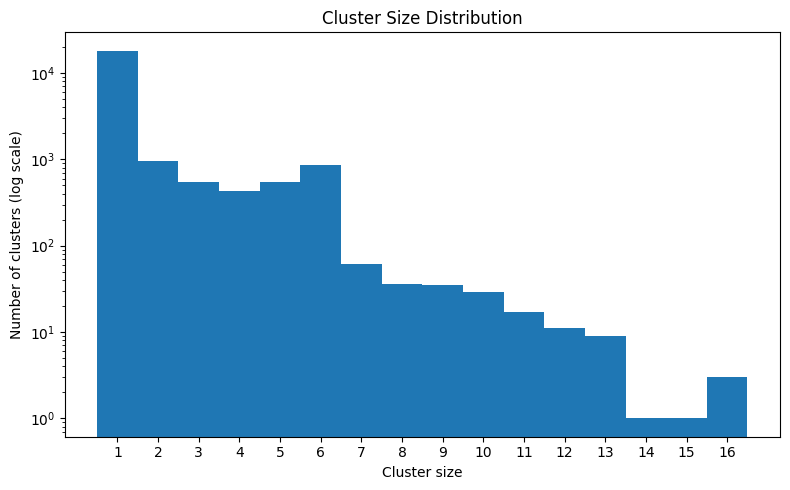

In [27]:
import matplotlib.pyplot as plt
import numpy as np

cluster_sizes = [len(c) for c in clusters]

plt.figure(figsize=(8, 5))
plt.hist(cluster_sizes, bins=np.arange(1, max(cluster_sizes) + 2) - 0.5)

plt.yscale("log")
plt.xlabel("Cluster size")
plt.ylabel("Number of clusters (log scale)")
plt.title("Cluster Size Distribution")

plt.xticks(range(1, max(cluster_sizes) + 1))
plt.tight_layout()
plt.show()

In [28]:
import random

eligible = [c for c in clusters if len(c) > 2]

random.seed = 123

sample_clusters = random.sample(eligible, min(10, len(eligible)))

for c in sample_clusters:
    print("=" * 90)
    print("cluster size:", len(c))

    for i in c:
        r = data[i]
        print(
            i,
            "| handle:", r.get("handle"),
            "| name:", r.get("name"),
            "| platform:", r.get("_platform"),
            "| time:", r.get("_year"), r.get("_month"),
            "| category:", r.get("category_unified"),
            "| followers:", r.get("followers")
        )

cluster size: 5
10279 | handle: Smile Family Spanish | name: Smile Family Spanish | platform: youtube | time: 2022 december | category: None | followers: 16800000.0
10941 | handle: Smile Family Spanish | name: Smile Family Spanish | platform: youtube | time: 2022 june | category: Entertainment | followers: 14800000.0
12357 | handle: Smile Family Spanish | name: Smile Family Spanish | platform: youtube | time: 2022 march | category: Entertainment | followers: 13900000.0
14300 | handle: Smile Family Spanish | name: Smile Family Spanish | platform: youtube | time: 2022 september | category: None | followers: 15900000.0
32632 | handle: @Smile Family Spanish | name: None | platform: youtube | time: 2026 None | category: None | followers: None
cluster size: 6
655 | handle: juventus | name: Juventus | platform: instagram | time: 2022 december | category: Sports | followers: 55900000.0
1441 | handle: juventus | name: Juventus | platform: instagram | time: 2022 june | category: Sports | followe

In [29]:
import random
import re

def norm_text(s):
    if s is None:
        return ""
    s = str(s).lower().strip()
    s = s.replace("@", "")
    s = re.sub(r"[^a-z0-9]+", "", s)
    return s

def cluster_has_name_or_handle_variation(cluster):
    handles = {norm_text(data[i].get("handle")) for i in cluster}
    names = {norm_text(data[i].get("name")) for i in cluster}

    handles.discard("")
    names.discard("")

    return len(handles) > 1 and len(names) > 1

eligible = [
    c for c in clusters
    if len(c) > 1 and cluster_has_name_or_handle_variation(c)
]

print("Eligible clusters:", len(eligible))

sample_clusters = random.sample(eligible, min(10, len(eligible)))

for c in sample_clusters:
    print("=" * 90)
    print("cluster size:", len(c))

    for i in c:
        r = data[i]
        print(
            i,
            "| handle:", r.get("handle"),
            "| name:", r.get("name"),
            "| platform:", r.get("_platform"),
            "| time:", r.get("_year"), r.get("_month"),
            "| category:", r.get("category_unified"),
            "| followers:", r.get("followers")
        )

Eligible clusters: 127
cluster size: 5
10432 | handle: Vlad and Niki ARA | name: Vlad and Niki ARA | platform: youtube | time: 2022 december | category: None | followers: 14200000.0
10959 | handle: Vlad and Niki ARA | name: Vlad and Niki ARA | platform: youtube | time: 2022 june | category: None | followers: 12900000.0
13430 | handle: Vlad and Niki ARA | name: Vlad and Niki ARA | platform: youtube | time: 2022 november | category: None | followers: 14200000.0
14683 | handle: Vlad and Niki PRT | name: Vlad and Niki PRT | platform: youtube | time: 2022 september | category: None | followers: 11400000.0
32421 | handle: @Vlad and Niki Arabic | name: None | platform: youtube | time: 2026 None | category: None | followers: None
cluster size: 2
24463 | handle: cholojuanitoyricharddouglas | name: Juanito y Richard | platform: youtube | time: 2024 None | category: None | followers: 1300000.0
30130 | handle: juanitoyrichard | name: Cholo Juanito Richard Douglas | platform: tiktok | time: 2024 No

Evaluation : generate synthetic data

In [31]:
import json
import itertools
from collections import defaultdict

# ============================================================
# 1. Populate uniqueId from clusters
# ============================================================

for unique_id, members in enumerate(clusters):
    for node_id in members:
        data[node_id]["uniqueId"] = unique_id

# remove neighbors before saving
final_data = []
for row in data:
    row = dict(row)
    row.pop("neighbors", None)
    final_data.append(row)

with open("graphsage_final_uniqueId.json", "w", encoding="utf-8") as f:
    json.dump(final_data, f, indent=2, ensure_ascii=False)

print("Saved: graphsage_final_uniqueId.json")


# ============================================================
# 2. Same evaluation calculation as your synthetic tester
#    Requires:
#      - true_person_id
#      - uniqueId
# ============================================================

def reviewGraphSAGEClustering(data):
    tp = 0
    tn = 0
    fp = 0
    fn = 0

    for i, j in itertools.combinations(range(len(data)), 2):
        same_true = data[i]["true_person_id"] == data[j]["true_person_id"]
        same_pred = data[i].get("uniqueId") == data[j].get("uniqueId")

        if same_true and same_pred:
            tp += 1
        elif same_true and not same_pred:
            fn += 1
        elif not same_true and same_pred:
            fp += 1
        else:
            tn += 1

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print("========== REVIEW GRAPHSAGE PIPELINE ==========")
    print("rows :", len(data))
    print("true influencers :", len(set(r["true_person_id"] for r in data)))
    print("predicted clusters :", len(set(r["uniqueId"] for r in data)))
    print("")
    print("TP :", tp)
    print("FP :", fp)
    print("TN :", tn)
    print("FN :", fn)
    print("")
    print("FPR :", round(fpr, 4))
    print("FNR :", round(fnr, 4))
    print("Precision :", round(precision, 4))
    print("Recall :", round(recall, 4))

    print("\n========== SAMPLE BY TRUE PERSON ==========\n")

    shown = set()
    for r in data:
        pid = r["true_person_id"]
        if pid in shown:
            continue

        print("TRUE PERSON:", pid)
        rows = [x for x in data if x["true_person_id"] == pid][:5]

        for rr in rows:
            print(
                "   ",
                rr.get("handle"),
                "|",
                rr.get("name"),
                "| predicted uniqueId:",
                rr.get("uniqueId")
            )

        print("")
        shown.add(pid)

        if len(shown) >= 5:
            break

    return {
        "data": data,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "fpr": fpr,
        "fnr": fnr,
        "precision": precision,
        "recall": recall,
    }


#results = reviewGraphSAGEClustering(final_data)

Saved: graphsage_final_uniqueId.json


Loaded neighbor file: distances_similarity_no_impossible_edges.json

########################################################################################################################
Total clusters: 21699
Singleton clusters: 18148
Singleton clusters with at least 1 neighbor: 20 sampled
Non-singleton clusters: 3551
########################################################################################################################


########################################################################################################################
RANDOM SAMPLE OF 20 SINGLETON CLUSTERS WITH NEIGHBORS
########################################################################################################################

SINGLETON CLUSTER 16816
POINT:
  dumbId=26992 | handle='presstube' | name='PressTube' | category=None | year=2024 | month=None | platform='tiktok' | uniqueId=16816

CLOSEST 5 NEIGHBORS:
  similarity=0.4444
   -> dumbId=10396 | handle='XpressTV' | name='Xpre

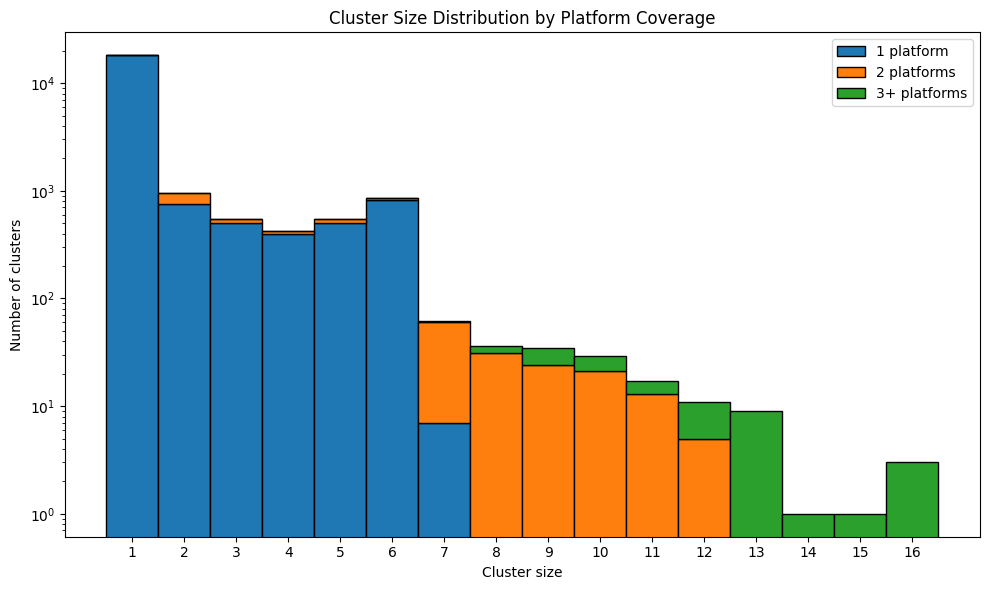

Total clusters: 21699
Total rows: 33174


In [32]:
import json
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# Load already-created GraphSAGE clustering file
# ============================================================

PATH = "graphsage_final_uniqueId.json"

with open(PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


# ============================================================
# Rebuild uniqueId -> set(dumbId) cluster map
# ============================================================

uniqueId = defaultdict(set)

for i, row in enumerate(data):
    uid = row.get("uniqueId")
    dumb_id = int(row.get("dumbId", i))
    uniqueId[uid].add(dumb_id)

# for easy lookup by dumbId
by_id = {
    int(row.get("dumbId", i)): row
    for i, row in enumerate(data)
}


# ============================================================
# Formatting helpers
# ============================================================

def fmt_record(r):
    handle = r.get("handle")
    name = r.get("name")
    cat = r.get("category_unified")
    year = r.get("_year")
    month = r.get("_month", "")
    platform = r.get("_platform")
    dumb_id = r.get("dumbId")

    return (
        f"dumbId={dumb_id} | "
        f"handle={repr(handle)} | "
        f"name={repr(name)} | "
        f"category={repr(cat)} | "
        f"year={repr(year)} | "
        f"month={repr(month)} | "
        f"platform={repr(platform)} | "
        f"uniqueId={repr(r.get('uniqueId'))}"
    )


def print_singleton(cluster_id):
    cluster = uniqueId[cluster_id]

    if len(cluster) != 1:
        return

    point_id = next(iter(cluster))
    row = by_id[point_id]

    print("=" * 120)
    print(f"SINGLETON CLUSTER {cluster_id}")
    print("POINT:")
    print("  " + fmt_record(row))


def print_cluster(cluster_id):
    cluster = uniqueId[cluster_id]

    print("=" * 120)
    print(f"NON-SINGLETON CLUSTER {cluster_id} | size={len(cluster)}")

    members = [by_id[idx] for idx in cluster]
    members = sorted(
        members,
        key=lambda r: (
            str(r.get("handle")),
            str(r.get("name")),
            str(r.get("_year")),
            str(r.get("_month", "")),
            str(r.get("_platform")),
        ),
    )

    for m in members:
        print("  " + fmt_record(m))


# ============================================================
# Optional: if your final JSON has no neighbors, inspect
# singleton clusters by original candidate graph file
# ============================================================

def load_neighbors_if_available(path="distances_similarity_no_impossible_edges.json"):
    try:
        with open(path, "r", encoding="utf-8") as f:
            original = json.load(f)

        neighbor_map = {
            int(row.get("dumbId", i)): row.get("neighbors", [])
            for i, row in enumerate(original)
        }

        original_by_id = {
            int(row.get("dumbId", i)): row
            for i, row in enumerate(original)
        }

        print("Loaded neighbor file:", path)
        return neighbor_map, original_by_id

    except FileNotFoundError:
        print("Neighbor file not found. Singleton-neighbor inspection will be skipped.")
        return None, None


neighbor_map, original_by_id = load_neighbors_if_available()


def print_singleton_with_neighbors(cluster_id, max_neighbors=5):
    cluster = uniqueId[cluster_id]

    if len(cluster) != 1:
        return

    point_id = next(iter(cluster))
    row = by_id[point_id]

    print("=" * 120)
    print(f"SINGLETON CLUSTER {cluster_id}")
    print("POINT:")
    print("  " + fmt_record(row))

    if neighbor_map is None:
        print("  No neighbor file loaded.")
        return

    neighbors = neighbor_map.get(point_id, [])

    if not neighbors:
        print("  No neighbors found.")
        return

    print(f"\nCLOSEST {min(max_neighbors, len(neighbors))} NEIGHBORS:")

    for neighbor_id, sim in neighbors[:max_neighbors]:
        neighbor_id = int(neighbor_id)
        neigh = original_by_id[neighbor_id]

        print(f"  similarity={float(sim):.4f}")
        print("   -> " + fmt_record(neigh))


def sample_singletons_with_neighbors(target_n=20):
    if neighbor_map is None:
        return []

    eligible = []

    for cid, cluster in uniqueId.items():
        if len(cluster) != 1:
            continue

        point_id = next(iter(cluster))

        if len(neighbor_map.get(point_id, [])) > 0:
            eligible.append(cid)

    n = min(target_n, len(eligible))
    return random.sample(eligible, n)


# ============================================================
# Plot cluster platform distribution
# ============================================================

def plot_cluster_platform_distribution(uniqueId, exclude_none_cluster=True, log_y=True):
    size_1 = []
    size_2 = []
    size_3plus = []

    for cluster_id, members in uniqueId.items():
        if exclude_none_cluster and cluster_id is None:
            continue

        if not members:
            continue

        platforms = {
            str(by_id[idx].get("_platform")).lower()
            for idx in members
        }

        nb_platforms = len(platforms)
        size = len(members)

        if nb_platforms == 1:
            size_1.append(size)
        elif nb_platforms == 2:
            size_2.append(size)
        else:
            size_3plus.append(size)

    all_sizes = size_1 + size_2 + size_3plus

    if not all_sizes:
        print("No clusters to plot.")
        return

    max_size = max(all_sizes)
    bins = np.arange(1, max_size + 2) - 0.5

    plt.figure(figsize=(10, 6))
    plt.hist(
        [size_1, size_2, size_3plus],
        bins=bins,
        stacked=True,
        label=["1 platform", "2 platforms", "3+ platforms"],
        edgecolor="black"
    )

    plt.xticks(range(1, max_size + 1))
    plt.xlabel("Cluster size")
    plt.ylabel("Number of clusters")
    plt.title("Cluster Size Distribution by Platform Coverage")

    if log_y:
        plt.yscale("log")

    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Main manual review helper
# ============================================================

def manual_review(seed=42, target_n=20):
    random.seed = seed

    singleton_cluster_ids = [
        cid for cid, cluster in uniqueId.items()
        if len(cluster) == 1
    ]

    nonsingleton_cluster_ids = [
        cid for cid, cluster in uniqueId.items()
        if len(cluster) > 1
    ]

    sampled_singletons = sample_singletons_with_neighbors(target_n=target_n)

    sampled_multi = random.sample(
        nonsingleton_cluster_ids,
        min(target_n, len(nonsingleton_cluster_ids))
    )

    print("\n" + "#" * 120)
    print(f"Total clusters: {len(uniqueId)}")
    print(f"Singleton clusters: {len(singleton_cluster_ids)}")
    print(f"Singleton clusters with at least 1 neighbor: {len(sampled_singletons)} sampled")
    print(f"Non-singleton clusters: {len(nonsingleton_cluster_ids)}")
    print("#" * 120 + "\n")

    print("\n" + "#" * 120)
    print(f"RANDOM SAMPLE OF {len(sampled_singletons)} SINGLETON CLUSTERS WITH NEIGHBORS")
    print("#" * 120 + "\n")

    for cid in sampled_singletons:
        print_singleton_with_neighbors(cid, max_neighbors=5)

    print("\n" + "#" * 120)
    print(f"RANDOM SAMPLE OF {len(sampled_multi)} NON-SINGLETON CLUSTERS")
    print("#" * 120 + "\n")

    for cid in sampled_multi:
        print_cluster(cid)

    plot_cluster_platform_distribution(uniqueId)

    print("Total clusters:", len(uniqueId))
    print("Total rows:", len(data))


manual_review()

In [33]:
import os
import shutil
import glob

# final file you want to keep/move
SOURCE_FINAL = "graphsage_final_uniqueId.json"
TARGET_DIR = "sage - alternative merging"
TARGET_FINAL = os.path.join(TARGET_DIR, "final.csv")

os.makedirs(TARGET_DIR, exist_ok=True)

# move/copy final file first
shutil.copy2(SOURCE_FINAL, TARGET_FINAL)
print("Saved final file to:", TARGET_FINAL)

# files generated during this GraphSAGE/cluster workflow
generated_files = [
    "distances_similarity.json",
    "distances_similarity_no_impossible_edges.json",
    "graphsage_embeddings.npy",
    "graphsage_constrained_clusters.json",
    "graphsage_constrained_clusters_strict.json",
    "graphsage_final_uniqueId.json",
    "graphsage_final_uniqueID.json",
]

# remove generated files except target final
for path in generated_files:
    if os.path.exists(path):
        os.remove(path)
        print("Removed:", path)

print("Done.")

Saved final file to: sage - alternative merging/final.csv
Removed: distances_similarity_no_impossible_edges.json
Removed: graphsage_embeddings.npy
Removed: graphsage_constrained_clusters_strict.json
Removed: graphsage_final_uniqueId.json
Done.
